# Bouncing Ball Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton.

![Cruise Control Diagram](./figures/bouncing_ball_hybrid_automaton.png)

In [15]:
from hybrid_automatons import bouncing_ball
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import matplotlib.pyplot as plt
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, transitions_times_over_time_fig, automaton_states_over_time 
import numpy as np
ha: Automaton = bouncing_ball(gravity=-9.81, restitution=0.8)
print (ha)

Hybrid Automaton Definition:
	name: Bouncing Ball
	id: 4
	initial_mode: FLYING
	modes: [FLYING, GROUND]
	transitions:
		FLYING --[hit_ground]--> GROUND
		GROUND --[bounce_up]--> FLYING
		GROUND --[stop]--> GROUND
	guards:
		hit_ground: [hits_ground]
		bounce_up: [bounce_possible]
		stop: [no_more_bounce]
	resets:
		hit_ground: bounce_reset
		bounce_up: <none>
		stop: stop_reset
	invariants:
		FLYING: [<none>]
		GROUND: [<none>]
	continous_dynamics:
		FLYING -> flying_flow
		GROUND -> ground_flow



In [16]:
print (f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}")

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> FLYING
    FLYING --> GROUND: hit_ground
    GROUND --> FLYING: bounce_up
    GROUND --> GROUND: stop


## Automaton Runner

In [17]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
await ha_runner.run(
    x0=np.array([5.0, 0.0]), collect_auxiliary=False, collect_control=False, real_time_mode=False, integrate=True, duration=30.0, dt=0.01
)
ha_runner.print_summary()

>>> Starting bouncing ball
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[E

## Evaluation


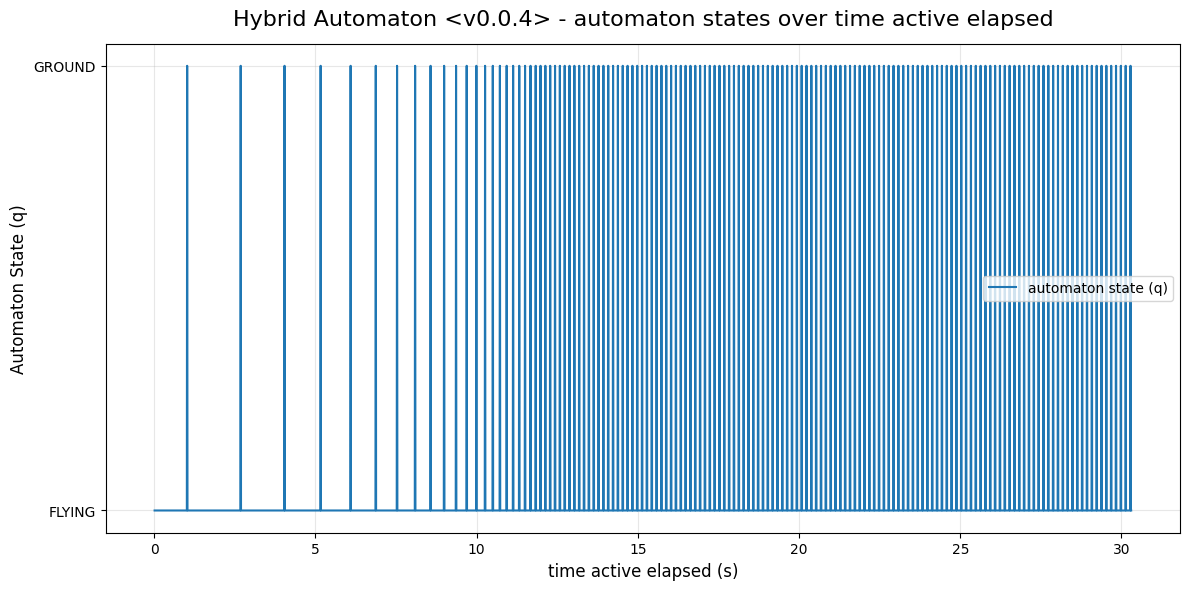

In [18]:
results = ha_runner.get_results()
# fig1 = continuous_states_over_time_fig(results['continuous_states'])
# fig4 = transitions_times_over_time_fig(results['transition_times'])
fig5 = automaton_states_over_time(results['automaton_states'])
plt.show()